In [113]:
import numpy as np
import matplotlib.pyplot as plt
from empymod import bipole
from pygimli.physics.ves import VESModelling
from objfun import showPhiD

In [ ]:
def forward(res, thk, L=40, time=None):
    """Compute TEM forward response for given resistivity and thickness.

    Parameter
    ---------
    res : array
        this is my resistivity (but only subsurface)
    thk : array (one shorter than res)
        thickness of the (N-1) layers (last is infinite)
    L : float [40]
        loop edge length
    time : array
        gate time at which transient is measured
    """
    if time is None:
        time = np.logspace(-6, -2, 41)

    tx = [-L/2, L/2, L/2, -L/2, -L/2]
    ty = [L/2, L/2, -L/2, -L/2, L/2]
    return bipole(res=np.concatenate([[2e14], res]),
        depth=np.concatenate([[0], np.cumsum(thk)]), # convert thickness into depths! (cumsum) [0], cumsum(...)
        src=[tx[:-1], tx[1:], ty[:-1], ty[1:], 0, 0],
        rec=[0, 0, 0, 0, 90],
        signal=-1,
        strength=1/L**2,
        mrec="b",
        verb=0, # silent
        freqtime=time, # Wanted times.
        srcpts=3,
        ftarg={"dlf": "key_81_2009"},  # Shorter, faster filters.
        # htarg={"dlf": "key_101_2009", "pts_per_dec": -1},
        ).sum(axis=1)

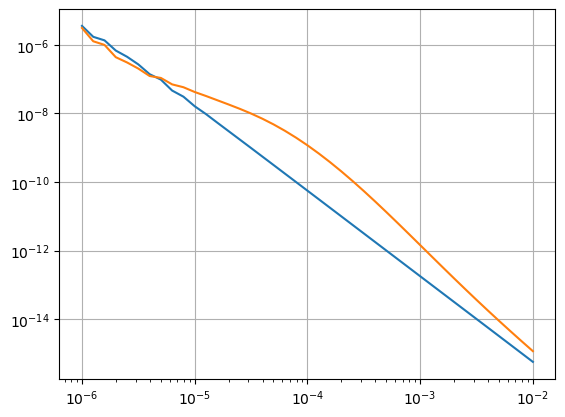

In [134]:
time = np.logspace(-6, -2, 41)
dataH = forward([200, 200, 200], [20, 20]);#, L=100)
data = forward([200, 10, 200], [20, 20]);#, L=100)
plt.loglog(time, dataH)
plt.loglog(time, data)
plt.grid();

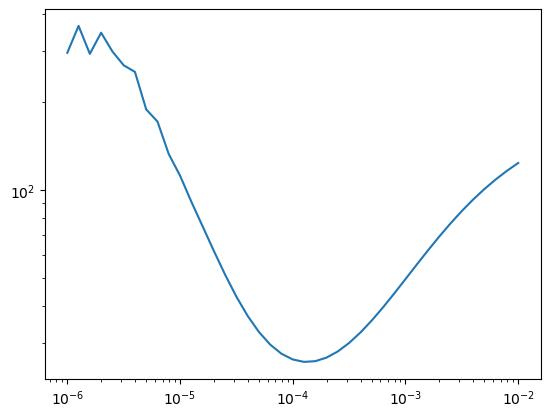

In [135]:
def rhoa(t, dbzdt, m=1.0):
    mu0 = 4e-7 * np.pi
    return mu0/np.pi*(mu0*m/20)**(2/3)*np.abs(dbzdt)**(-2/3)*t**(-5/3)

plt.loglog(time, rhoa(time, data));

In [106]:
phiD = lambda x, y, err: np.mean((np.log(x)-np.log(y))**2/err**2)
thk2 = np.logspace(0.5, 2, 31)
res2 = np.logspace(0.5, 2, 31)
M = np.zeros((len(thk2), len(res2)))
res = [200, 200, 200]
thk = [20, 20]
error = 0.02
dataN = data * (1+np.random.randn(len(data))*error)
for i, res[1] in enumerate(thk2):
    for j, thk[1] in enumerate(res2):
        M[i, j] = phiD(data, forward(res, thk), error)

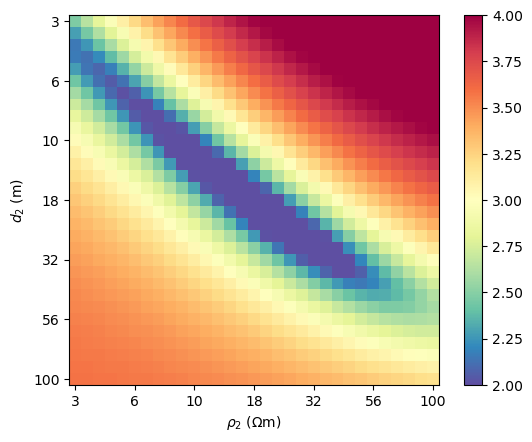

In [108]:
showPhiD(res2, thk2, np.log10(M), vmin=2, vmax=4);

In [83]:
ab2 = np.logspace(0.8, 3.5, 50)
ves = VESModelling(ab2=ab2, mn2=ab2/3)
dataVes = ves.response([20, 20, 200, 20, 200]) * (np.random.randn(len(ab2)) * error + 1.0)

In [90]:
resV = [200, 200, 200]
thkV = [20, 20]
MVES = np.zeros((len(thk2), len(res2)))
for i, thkV[1] in enumerate(thk2):
    for j, resV[1] in enumerate(res2):
        MVES[i, j] = phiD(dataVes, ves.response(thkV+resV), error)

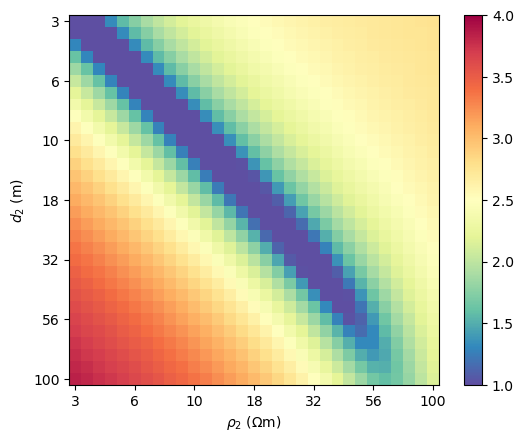

In [109]:
showPhiD(res2, thk2, np.log10(MVES));

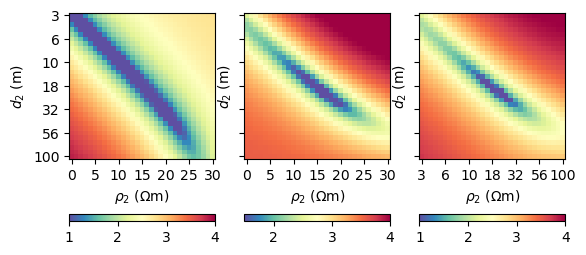

In [112]:
fig, ax = plt.subplots(ncols=3, sharey=True)
showPhiD(res2, thk2, np.log10(MVES), vmin=1, vmax=4, ax=ax[0], orientation='horizontal');
showPhiD(res2, thk2, np.log10(M), vmin=1.5, vmax=4, ax=ax[1], orientation='horizontal');
showPhiD(res2, thk2, np.log10((MVES+M)/2), vmin=1, vmax=4, ax=ax[2], orientation='horizontal');